# Adult Income Prediction

## End-to-End Machine Learning Project

### Problem Statement

The objective of this project is to predict whether an individual's annual
income is less than or equal to 50K or greater than 50K using demographic,
educational, occupational and employment-related information.

This is a binary classification problem.

## 1. Importing Required Libraries

In this section, the libraries required for data analysis, visualization,
preprocessing and machine learning are imported.

Pandas is used for handling tabular data and NumPy is used for numerical
operations. Matplotlib and Seaborn are used for visualization.
Scikit-learn is used for preprocessing, model building and evaluation.

In [120]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay

print("Libraries imported successfully")

Libraries imported successfully


## 2. Loading the Dataset

The Adult Income dataset is stored in CSV format.

The dataset is loaded using Pandas. After loading it, the number of rows
and columns is displayed to understand the size of the dataset.

In [121]:
import numpy as np
import pandas as pd
url=("adult.csv")
df = pd.read_csv("adult.csv")

print("Dataset loaded successfully")
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Dataset loaded successfully
Number of rows: 32561
Number of columns: 15


## 3. Viewing the Dataset

The first few rows are displayed to understand the structure of the dataset
and the type of information contained in each column.

In [122]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## 4. Understanding the Features

The column names are displayed to identify the input features and the target
variable.

The income column will be used as the target because it is the value that
the machine learning model needs to predict.

In [123]:
print("columns in the dataset:")
for column in df.columns:
    print(column)

columns in the dataset:
age
workclass
fnlwgt
education
education.num
marital.status
occupation
relationship
race
sex
capital.gain
capital.loss
hours.per.week
native.country
income


## 5. Dataset Information

The info() function provides information about the columns, data types and
non-null values.

This is useful for deciding how numerical and categorical features should
be processed.

In [124]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


## 6. Statistical Summary

The describe() function provides statistical information about numerical
features.

The output contains values such as mean, standard deviation, minimum,
maximum and quartiles.

In [125]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


## 7. Checking Missing Values

Missing values can affect the performance of machine learning models.

First, standard Pandas missing values are checked in every column.

In [126]:
missing_values=df.isnull().sum()
print("missing values:")
print(missing_values)

missing values:
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64


## 8. Checking Unknown Values

The Adult dataset represents some unknown categorical values using the
symbol '?'.

These values need to be identified because they should be treated as
missing values during preprocessing.

In [127]:
unknown_values = (df == "?").sum()

print("Unknown values represented by '?':")
print(unknown_values)

Unknown values represented by '?':
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


## 9. Converting Unknown Values to Missing Values

The '?' symbol is converted into NaN.

NaN is the standard representation of missing data in Pandas and allows
the missing values to be handled systematically during preprocessing.

In [128]:
df=df.replace("?",np.nan)
print("missing values after conversion:")
print(df.isnull().sum())

missing values after conversion:
age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


## 10. Checking Duplicate Records

Duplicate rows are checked because repeated observations do not provide
additional information and may influence the model.

If duplicates are found, they will be removed.

In [129]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 24


## 11. Removing Duplicate Records

The duplicate rows are removed from the dataset.

This gives us a cleaner dataset for further analysis and model training.

In [130]:
df=df.drop_duplicates()
print("shape after removing duplicates:",df.shape)

shape after removing duplicates: (32537, 15)


## 12. Rechecking Missing Values

After converting '?' to NaN and removing duplicate records, the missing
values are checked again.

The result tells us which features require imputation during preprocessing.

In [131]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     582
income               0
dtype: int64


# 13. Exploratory Data Analysis

Exploratory Data Analysis is performed to understand patterns and
relationships in the dataset.

We begin by examining the distribution of the target variable, income.

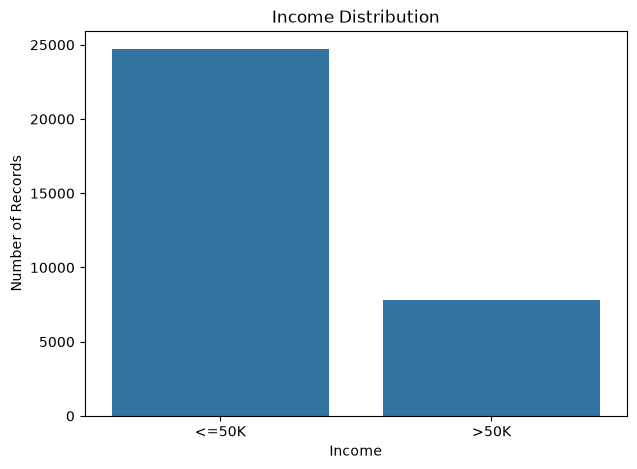

In [132]:
plt.figure(figsize=(7,5))
sns.countplot(data=df,x="income")
plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Records")
plt.show()

## 14. Income Class Counts

The number of observations in each income category is calculated.

This helps us determine whether the target classes are balanced.

In [133]:
income_counts=df["income"].value_counts()
print(income_counts)

income
<=50K    24698
>50K      7839
Name: count, dtype: int64


## 15. Income Class Percentages

The percentage of records belonging to each income class is calculated.

This is important because an imbalanced target can make accuracy alone
insufficient for evaluating a classification model.

In [134]:
income_percent=df["income"].value_counts(normalize=True)*100
print(income_percent.round(2))

income
<=50K    75.91
>50K     24.09
Name: proportion, dtype: float64


## 16. Age Distribution

Age is a numerical feature.

A histogram is used to understand the distribution of ages in the dataset.

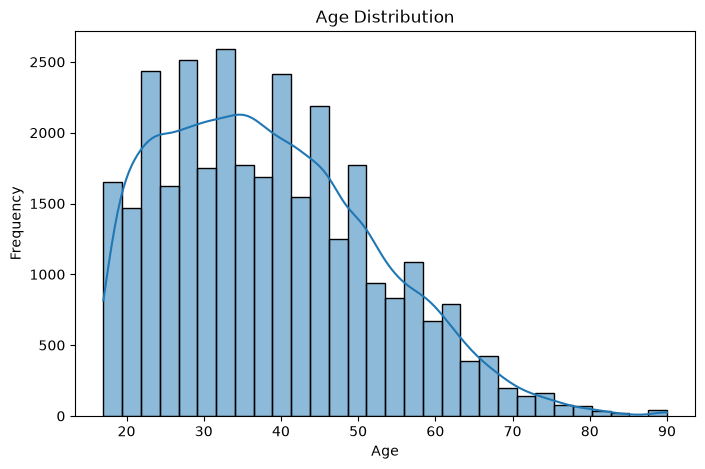

In [135]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="age",
    bins=30,
    kde=True
)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

## 17. Education Distribution

Education is a categorical feature.

A count plot is used to identify the most common education categories
present in the dataset.

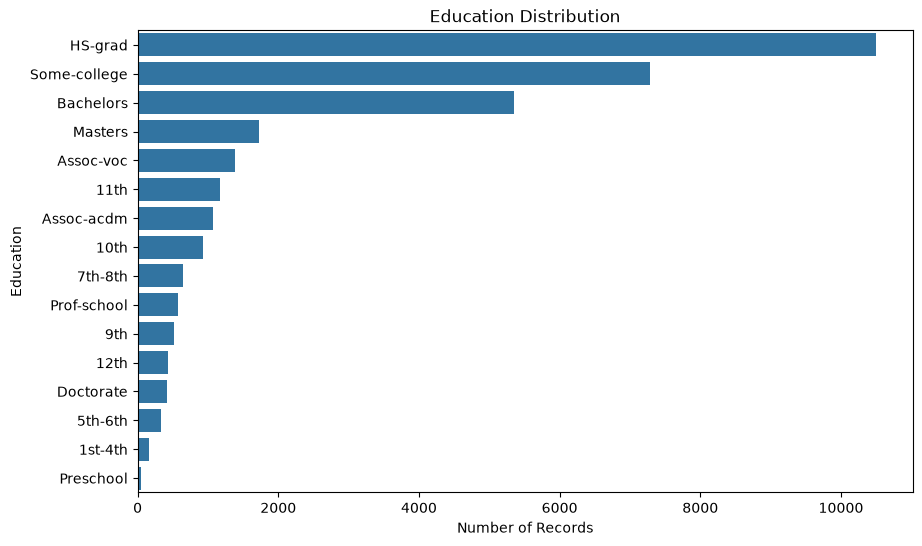

In [136]:
plt.figure(figsize=(10, 6))

education_order = df["education"].value_counts().index

sns.countplot(
    data=df,
    y="education",
    order=education_order
)

plt.title("Education Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Education")

plt.show()

## 18. Workclass Distribution

Workclass describes the employment category of an individual.

The distribution is visualized to understand which employment categories
are most common.

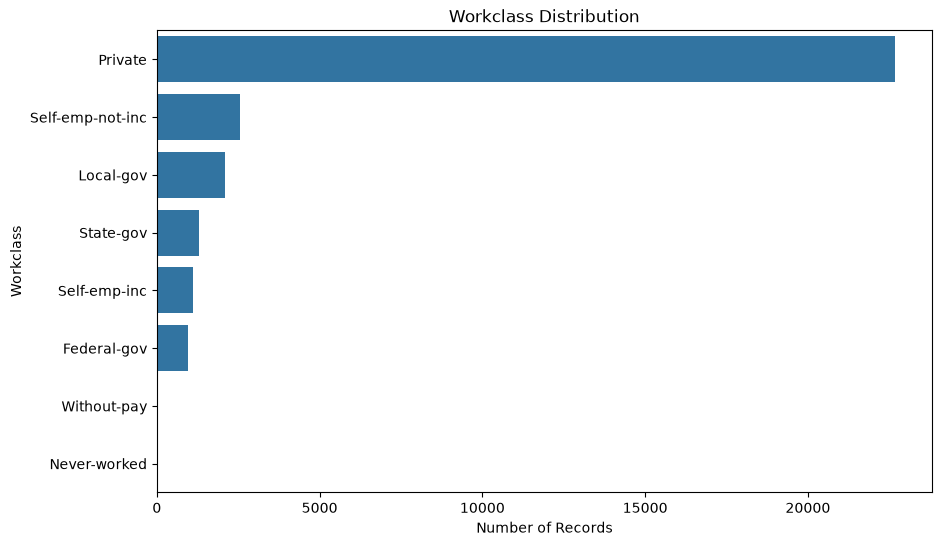

In [137]:
plt.figure(figsize=(10, 6))

workclass_order = df["workclass"].value_counts().index

sns.countplot(
    data=df,
    y="workclass",
    order=workclass_order
)

plt.title("Workclass Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Workclass")

plt.show()

## 19. Occupation Distribution

Occupation may have an important relationship with income.

The distribution of occupations is visualized to understand the different
job categories in the dataset.

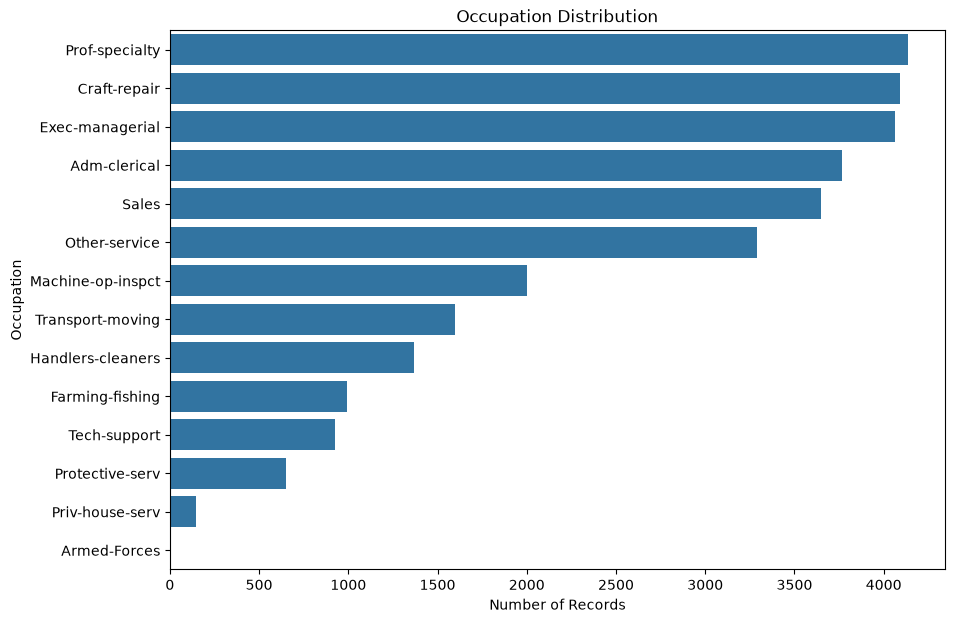

In [138]:
plt.figure(figsize=(10, 7))

occupation_order = df["occupation"].value_counts().index

sns.countplot(
    data=df,
    y="occupation",
    order=occupation_order
)

plt.title("Occupation Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Occupation")

plt.show()

## 20. Working Hours Distribution

The hours per week feature represents the number of hours an individual
works per week.

A histogram is used to understand its distribution.

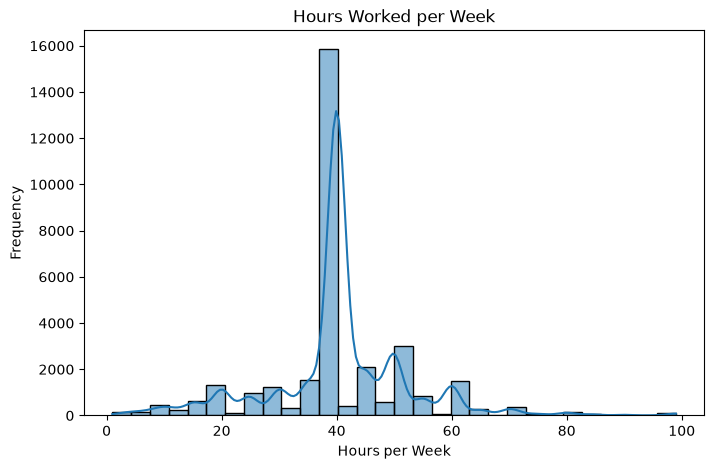

In [139]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="hours.per.week",
    bins=30,
    kde=True
)

plt.title("Hours Worked per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Frequency")

plt.show()

## 21. Education and Income

Education may have a relationship with income.

A count plot with income as the hue is used to compare the two income
categories across different education levels.

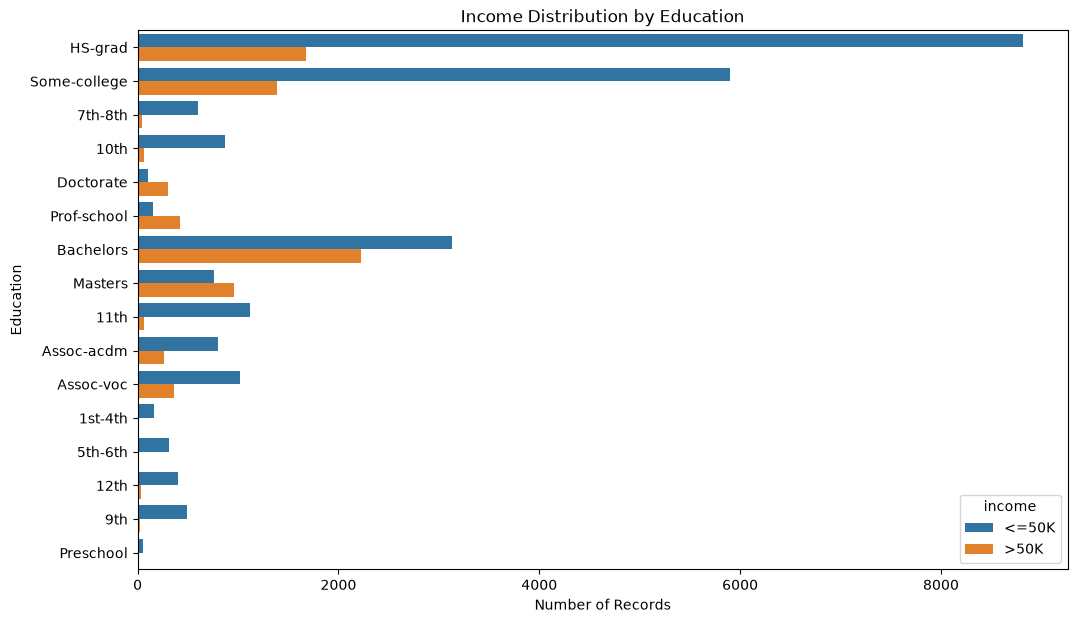

In [140]:
plt.figure(figsize=(12, 7))

sns.countplot(
    data=df,
    y="education",
    hue="income"
)

plt.title("Income Distribution by Education")
plt.xlabel("Number of Records")
plt.ylabel("Education")

plt.show()

## 22. Age and Income

A box plot is used to compare the age distributions of the two income
categories.

This helps identify whether age distributions differ between income groups.

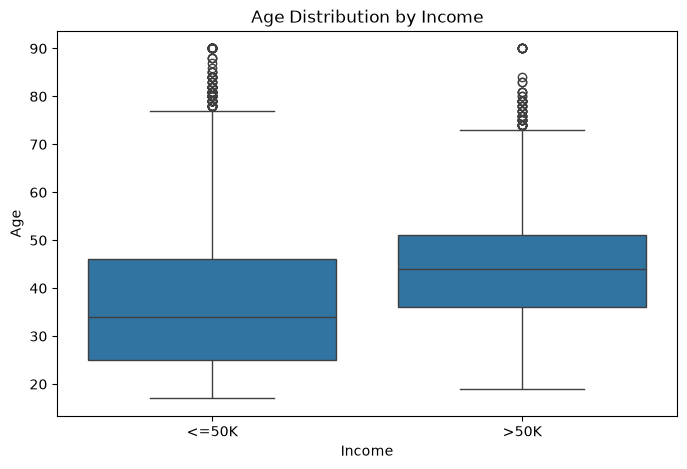

In [141]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="income",
    y="age"
)

plt.title("Age Distribution by Income")
plt.xlabel("Income")
plt.ylabel("Age")

plt.show()

## 23. Working Hours and Income

Working hours may have a relationship with income.

A box plot is used to compare weekly working hours between the income
categories.

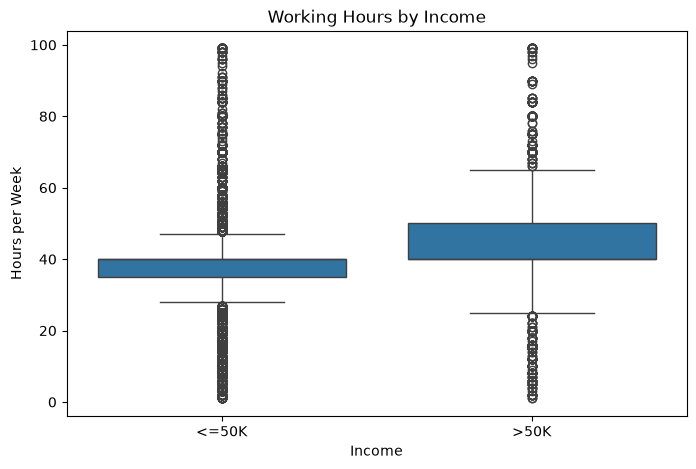

In [142]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="income",
    y="hours.per.week"
)

plt.title("Working Hours by Income")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.show()

## 24. Sex and Income

The sex feature is categorical.

A count plot is used to compare income categories across the different
values of the sex feature.

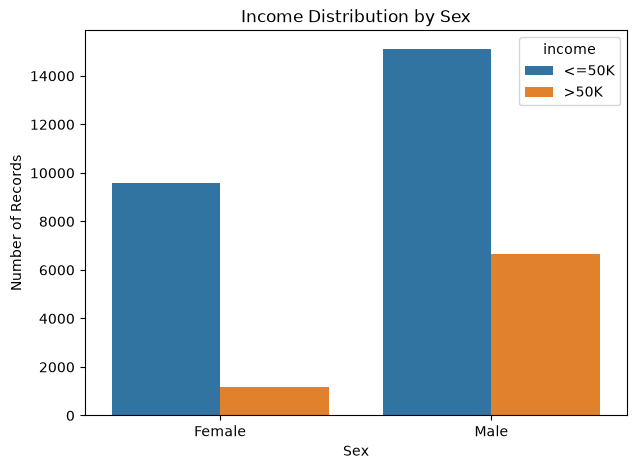

In [143]:
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="sex",
    hue="income"
)

plt.title("Income Distribution by Sex")
plt.xlabel("Sex")
plt.ylabel("Number of Records")

plt.show()

## 25. Correlation Analysis

Correlation is calculated for numerical features.

The correlation matrix helps identify the strength and direction of linear
relationships between numerical variables.

Correlation alone is not used to remove features because categorical
features can also contain important information.

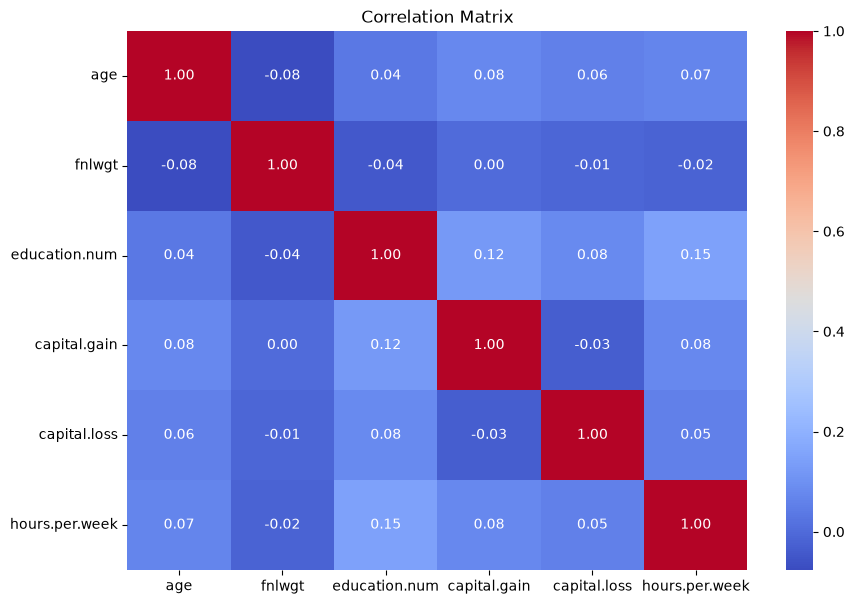

In [144]:
numeric_data = df.select_dtypes(include=np.number)

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

## 26. Outlier Analysis

Box plots are used to inspect numerical features for unusually high or
low observations.

Outliers are not automatically removed because some extreme values may
represent genuine individuals in the dataset.

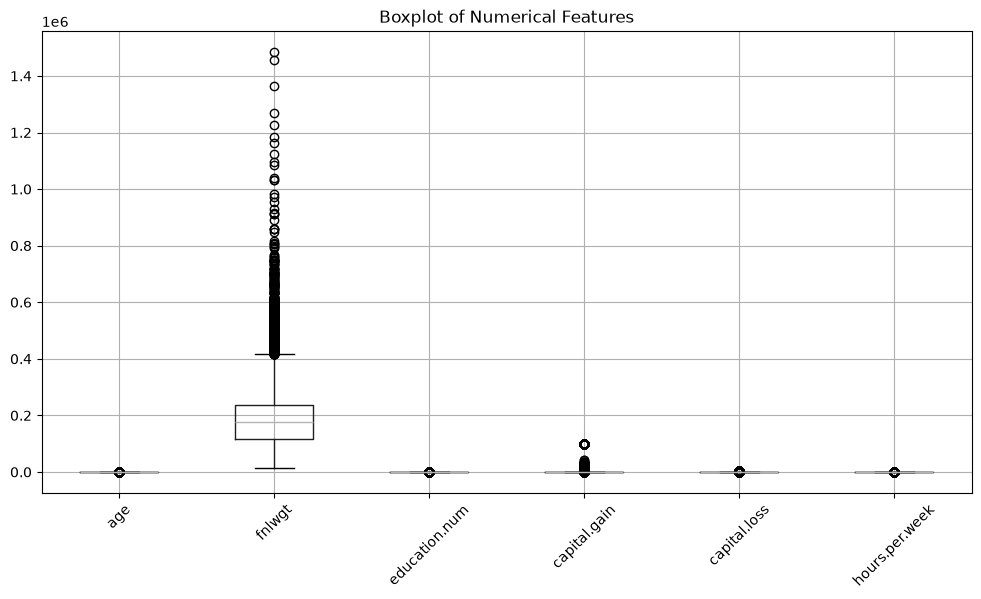

In [145]:
numeric_columns = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(12, 6))

df[numeric_columns].boxplot()

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

## 27. Separating Features and Target

The income column is the target variable because it is the value we want
to predict.

All other columns are treated as input features.

In [146]:
X = df.drop("income", axis=1)
y = df["income"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (32537, 14)
Target shape: (32537,)


## 28. Encoding the Target Variable

The target contains two categories.

They are converted into binary numerical values:

0 represents income <=50K.

1 represents income >50K.

This makes the target suitable for classification algorithms.

In [159]:
x=y.map({"<=50k":0,">50k":1})
print(y.value_counts())

income
0    24698
1     7839
Name: count, dtype: int64


In [147]:
# Encode the target variable

df["income"] = df["income"].astype(str).str.strip()

y = df["income"].map({
    "<=50K": 0,
    ">50K": 1
})

print("Target values:")
print(y.value_counts())

print("\nUnique encoded values:")
print(y.unique())

Target values:
income
0    24698
1     7839
Name: count, dtype: int64

Unique encoded values:
[0 1]


## 29. Identifying Numerical and Categorical Features

The dataset contains both numerical and categorical variables.

Numerical and categorical variables require different preprocessing
techniques, so they are identified separately.

In [148]:
numeric_features = X.select_dtypes(
    include=np.number
).columns.tolist()

categorical_features = X.select_dtypes(
    include="object"
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Categorical features:
['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country']


C:\Users\divin\AppData\Local\Temp\ipykernel_23500\345955849.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(


# Train/Test Split
## 30. Splitting the Dataset

The dataset is divided into training and testing data.

The training data is used to learn patterns, while the test data is kept
separate and used to evaluate the model on unseen observations.

80% of the data is used for training and 20% for testing.

Stratification is used to preserve the target-class distribution.

In [149]:
X_train, X_test, y_train, y_test = train_test_split( X,y,test_size=0.20,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (26029, 14)
Testing data: (6508, 14)


## 31. Data Preprocessing

The dataset contains missing values in some categorical columns.

For numerical features, missing values are replaced using the median.

For categorical features, missing values are replaced using the most
frequent category.

Categorical features are converted into numerical form using one-hot
encoding.

The preprocessing is placed inside a pipeline so that information from
the test set is not used when learning the preprocessing parameters.

In [150]:
numeric_pipeline = Pipeline([
    ("missing_values", SimpleImputer(strategy="median")),
    ("scaling", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("missing_values", SimpleImputer(strategy="most_frequent")),
    ("encoding", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

## 32. Logistic Regression

Logistic Regression is used as a baseline classification model.

It is relatively simple and provides a useful reference point for
comparing more complex algorithms.

In [151]:
logistic_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

print("Logistic Regression training completed")

Logistic Regression training completed


## 33. Decision Tree

A Decision Tree uses a sequence of decision rules to classify observations.

It can represent non-linear relationships and is easy to interpret.

In [152]:
tree_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

print("Decision Tree training completed")

Decision Tree training completed


## 34. Random Forest

Random Forest is an ensemble algorithm that combines multiple decision
trees.

It is suitable for tabular data and can capture complex relationships
between features.

In [153]:
forest_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

forest_model.fit(X_train, y_train)

forest_pred = forest_model.predict(X_test)

print("Random Forest training completed")

Random Forest training completed


## 35. Gradient Boosting

Gradient Boosting is an ensemble technique that builds models
sequentially.

Each new tree attempts to improve the errors made by the previous trees.
It is another suitable algorithm for a structured classification dataset.

In [154]:
boosting_model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=42))
])

boosting_model.fit(X_train, y_train)

boosting_pred = boosting_model.predict(X_test)

print("Gradient Boosting training completed")

Gradient Boosting training completed


## 36. Model Evaluation

Several evaluation metrics are used to compare the models.

Accuracy measures overall correctness.

Precision measures how many predicted positive cases are actually positive.

Recall measures how many actual positive cases were correctly identified.

F1-score provides a balance between precision and recall.

ROC-AUC measures the model's ability to distinguish between the two classes.

In [155]:
def evaluate_model(model_name, model, predictions, X_test, y_test):

    probabilities = model.predict_proba(X_test)[:, 1]

    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1 Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    }

## 37. Comparing the Models

The predictions from all four models are evaluated using the same metrics.

A comparison table is created so that the models can be compared objectively.

In [156]:
model_results = []

model_results.append(
    evaluate_model(
        "Logistic Regression",
        logistic_model,
        logistic_pred,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "Decision Tree",
        tree_model,
        tree_pred,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "Random Forest",
        forest_model,
        forest_pred,
        X_test,
        y_test
    )
)

model_results.append(
    evaluate_model(
        "Gradient Boosting",
        boosting_model,
        boosting_pred,
        X_test,
        y_test
    )
)

results_df = pd.DataFrame(model_results)

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8502,0.7344,0.5925,0.6558,0.9004
1,Decision Tree,0.8099,0.6052,0.6071,0.6062,0.7407
2,Random Forest,0.8467,0.7149,0.6046,0.6551,0.8925
3,Gradient Boosting,0.8591,0.7724,0.5886,0.6681,0.9138


## 38. Visual Comparison of Models

The evaluation metrics are displayed as a bar chart.

This makes it easier to compare the performance of the four algorithms.

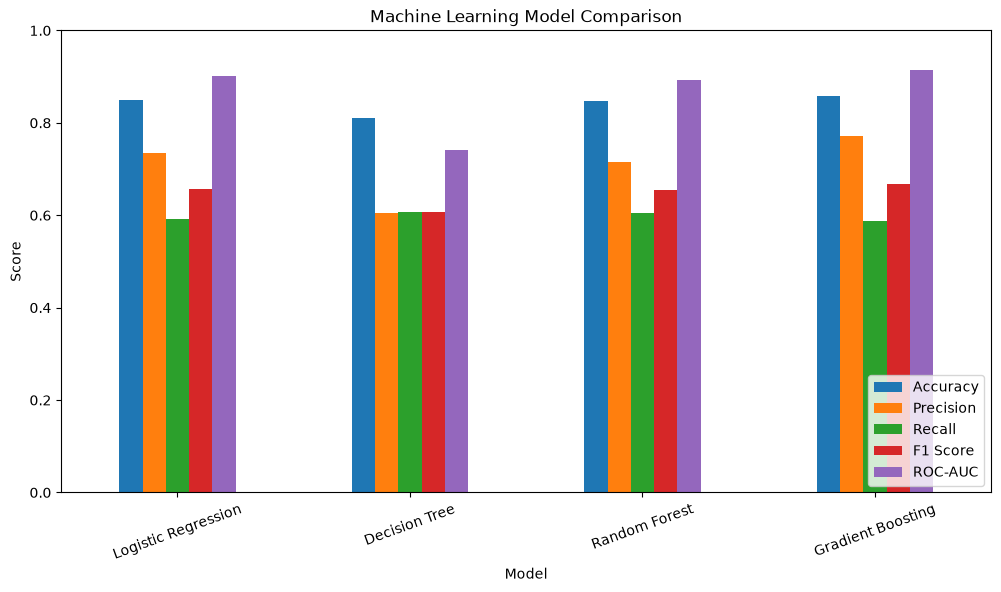

In [157]:
results_plot = results_df.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)

plt.xticks(rotation=20)
plt.legend(loc="lower right")

plt.show()

## 39. Selecting the Best Initial Model

The F1-score is used as the main comparison metric because the target
classes are not equally distributed.

The model with the highest F1-score is identified as the best initial
candidate.

In [158]:
best_index = results_df["F1 Score"].idxmax()

best_model_name = results_df.loc[
    best_index,
    "Model"
]

print("Best initial model:", best_model_name)

Best initial model: Gradient Boosting


## 40. Confusion Matrix

A confusion matrix provides a detailed view of classification results.

It shows how many observations were correctly and incorrectly classified
into each income category.

In [160]:
cm = confusion_matrix(
    y_test,
    forest_pred
)

print(cm)

[[4562  378]
 [ 620  948]]


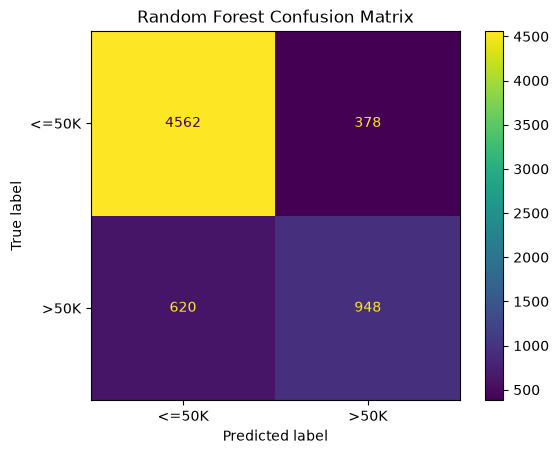

In [161]:
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["<=50K", ">50K"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

## 41. Classification Report

The classification report provides precision, recall and F1-score for
each target class.

This helps us understand whether the model performs equally well for
both income categories.

In [162]:
print(
    classification_report(
        y_test,
        forest_pred,
        target_names=["<=50K", ">50K"]
    )
)

              precision    recall  f1-score   support

       <=50K       0.88      0.92      0.90      4940
        >50K       0.71      0.60      0.66      1568

    accuracy                           0.85      6508
   macro avg       0.80      0.76      0.78      6508
weighted avg       0.84      0.85      0.84      6508



## 42. Hyperparameter Tuning

After comparing the initial models, hyperparameter tuning is performed
for the Random Forest model.

GridSearchCV tests different combinations of hyperparameters using
cross-validation.

The purpose is to find a parameter combination that gives better
validation performance without using the final test set for tuning.

In [163]:
from sklearn.model_selection import GridSearchCV

tuning_pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

parameter_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__max_depth": [10, 15],
    "classifier__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=parameter_grid,
    cv=3,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1-score:")
print(grid_search.best_score_)

Best parameters:
{'classifier__max_depth': 15, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 50}

Best cross-validation F1-score:
0.6744921666113862


## 43. Evaluating the Tuned Model

The tuned Random Forest is now evaluated on the test dataset.

The test data was not used during the parameter search, so it provides
an estimate of performance on unseen data.

In [164]:
tuned_pred = grid_search.predict(X_test)

tuned_probability = grid_search.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(y_test, tuned_pred)
tuned_recall = recall_score(y_test, tuned_pred)
tuned_f1 = f1_score(y_test, tuned_pred)
tuned_auc = roc_auc_score(y_test, tuned_probability)

print("Tuned Random Forest Results")
print("---------------------------")
print("Accuracy :", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall   :", round(tuned_recall, 4))
print("F1 Score :", round(tuned_f1, 4))
print("ROC-AUC  :", round(tuned_auc, 4))

Tuned Random Forest Results
---------------------------
Accuracy : 0.8573
Precision: 0.78
Recall   : 0.5676
F1 Score : 0.6571
ROC-AUC  : 0.9077


## 44. Final Model Comparison

The tuned Random Forest is added to the original model comparison.

This allows us to determine whether tuning improved the model compared
with the original algorithms.

In [165]:
tuned_result = pd.DataFrame([{
    "Model": "Tuned Random Forest",
    "Accuracy": tuned_accuracy,
    "Precision": tuned_precision,
    "Recall": tuned_recall,
    "F1 Score": tuned_f1,
    "ROC-AUC": tuned_auc
}])

final_results = pd.concat(
    [results_df, tuned_result],
    ignore_index=True
)

final_results = final_results.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

final_results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Gradient Boosting,0.8591,0.7724,0.5886,0.6681,0.9138
1,Tuned Random Forest,0.8573,0.7800,0.5676,0.6571,0.9077
2,Logistic Regression,0.8502,0.7344,0.5925,0.6558,0.9004
3,Random Forest,0.8467,0.7149,0.6046,0.6551,0.8925
4,Decision Tree,0.8099,0.6052,0.6071,0.6062,0.7407


## 45. Final Model Selection

The final model is selected based on the comparison of F1-score and
other evaluation metrics.

The selected model should provide a good balance between precision
and recall while also maintaining strong overall performance.

In [166]:
final_model_name = final_results.loc[0, "Model"]

print("Selected final model:", final_model_name)

Selected final model: Gradient Boosting


## 46. Prediction on New Unseen Data

A new observation is created to demonstrate how the trained model can
make a prediction for a person who was not present in the training
dataset.

The new observation contains the same input features used during training.

In [167]:
new_person = pd.DataFrame([{
    "age": 35,
    "workclass": "Private",
    "fnlwgt": 180000,
    "education": "Bachelors",
    "education.num": 13,
    "marital.status": "Married-civ-spouse",
    "occupation": "Exec-managerial",
    "relationship": "Husband",
    "race": "White",
    "sex": "Male",
    "capital.gain": 0,
    "capital.loss": 0,
    "hours.per.week": 45,
    "native.country": "United-States"
}])

new_person

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,35,Private,180000,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States


## 47. Making a Prediction

The tuned model is used to predict the income category of the new person.

The numerical output is converted into a meaningful income category.

In [168]:
new_prediction = grid_search.predict(new_person)

if new_prediction[0] == 1:
    print("Predicted income: >50K")
else:
    print("Predicted income: <=50K")

Predicted income: >50K


## 48. Prediction Probability

The model's probability estimates are displayed for both income classes.

This gives additional information about the confidence of the prediction.

In [169]:
new_probability = grid_search.predict_proba(new_person)[0]

print("Probability of <=50K:", round(new_probability[0], 4))
print("Probability of >50K :", round(new_probability[1], 4))

Probability of <=50K: 0.2408
Probability of >50K : 0.7592


## 49. Saving the Results

The cleaned dataset and model comparison results are saved as CSV files.

Saving these files makes the project easier to reproduce and inspect later.

## Feature Selection and Engineering Decision

The dataset already contains meaningful demographic, education, occupation
and employment-related features. Therefore, no unnecessary feature
engineering was performed.

The original features were retained because removing them without evidence
could result in loss of useful information.

The feature `education.num` provides a numerical representation of education
level, so it was retained along with the categorical `education` feature.

In [170]:
df.to_csv("adult_cleaned.csv", index=False)

final_results.to_csv(
    "model_comparison.csv",
    index=False
)

print("Files saved successfully")

Files saved successfully


# 50. Final Conclusion

In this project, an end-to-end Machine Learning classification system was
developed to predict whether an individual's annual income is <=50K or >50K.

The dataset was first examined to understand its structure, data types,
missing values and duplicate records. Unknown values represented by '?'
were converted into missing values, and duplicate records were removed.

Exploratory Data Analysis was then performed using statistical summaries
and visualizations. Important numerical and categorical features were
analyzed to understand their relationship with income.

The data was divided into training and testing sets. Numerical features
were scaled and categorical features were converted using one-hot encoding.
Missing values were handled through the preprocessing pipeline.

Four Machine Learning algorithms were compared:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting

The models were evaluated using accuracy, precision, recall, F1-score and
ROC-AUC. Since the target classes are imbalanced, F1-score was considered
an important metric during comparison.

Hyperparameter tuning was performed for Random Forest using GridSearchCV
and cross-validation.

The final model was selected based on the actual evaluation results.
Finally, the selected trained model was used to predict the income category
of a new unseen person.

Thus, the project demonstrates the complete Machine Learning workflow from
dataset understanding and preprocessing to model development, evaluation,
model selection and prediction.